### Feature Scaling and Outlier Detection ###

In [2]:
# To locate breast cancer data set
import sklearn.datasets as ds
dir(ds)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__getattr__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_arff_parser',
 '_base',
 '_california_housing',
 '_covtype',
 '_kddcup99',
 '_lfw',
 '_olivetti_faces',
 '_openml',
 '_rcv1',
 '_samples_generator',
 '_species_distributions',
 '_svmlight_format_fast',
 '_svmlight_format_io',
 '_twenty_newsgroups',
 'clear_data_home',
 'dump_svmlight_file',
 'fetch_20newsgroups',
 'fetch_20newsgroups_vectorized',
 'fetch_california_housing',
 'fetch_covtype',
 'fetch_file',
 'fetch_kddcup99',
 'fetch_lfw_pairs',
 'fetch_lfw_people',
 'fetch_olivetti_faces',
 'fetch_openml',
 'fetch_rcv1',
 'fetch_species_distributions',
 'get_data_home',
 'load_breast_cancer',
 'load_diabetes',
 'load_digits',
 'load_files',
 'load_iris',
 'load_linnerud',
 'load_sample_image',
 'load_sample_images',
 'load_svmlight_file',
 'load_svmlight_files',
 'load_wine',
 'make_biclusters',
 'make_blobs',
 'make_checkerboard

In [54]:
# To identify outlier using Z-score method
# To load Wisconsin breast cancer dataset from the sklearn.datasets module
from sklearn.datasets import load_breast_cancer

import pandas as pd

# Load Wisconsin breast cancer dataset as a pandas DataFrame
data_breastcancer = load_breast_cancer(as_frame=True)
df = data_breastcancer.frame

# To take two features
features = ['mean radius', 'mean texture']

# To calculate z-score
z_scores = (df[features] - df[features].mean()) / df[features].std()

# Add Z-scores as new columns
df['z_mean_radius'] = z_scores['mean radius']
df['z_mean_texture'] = z_scores['mean texture']

# Identify outliers
outliers = df[(z_scores > 3).any(axis=1) | (z_scores < -3).any(axis=1)]

# Boolean column: True if Z-score > 3 or < -3 in any feature
df['isOutlier_Z'] = (z_scores.abs() > 3).any(axis=1)

z_outliers = df[df['isOutlier_Z']]

# Display outliers with their Z-scores
print("Number of outliers detected:", outliers.shape[0])
print("\n")
print(z_outliers[['mean radius', 'z_mean_radius',
                  'mean texture', 'z_mean_texture',
                  'isOutlier_Z']])


Number of outliers detected: 9


     mean radius  z_mean_radius  mean texture  z_mean_texture  isOutlier_Z
82         25.22       3.147717         24.91        1.306744         True
180        27.22       3.715246         21.87        0.599937         True
212        28.11       3.967796         18.47       -0.190570         True
219        19.53       1.533097         32.47        3.064460         True
232        11.22      -0.824986         33.81        3.376013         True
239        17.46       0.945704         39.28        4.647799         True
259        15.53       0.398039         33.56        3.317887         True
352        25.73       3.292437         17.46       -0.425397         True
461        27.42       3.771999         26.27        1.622947         True


In [58]:
# To calculate outliers using IQR method
features = ['mean radius', 'mean texture']
subset_features = df[features]

# Calculate Q1 and Q3
Q1 = subset_features.quantile(0.25)
Q3 = subset_features.quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Boolean for outliers
is_outlier_iqr = ((subset_features < lower_bound) | (subset_features > upper_bound)).any(axis=1)

# Add column to DataFrame
df['isOutlier_IQR'] = is_outlier_iqr

# To display outliers
print("Total outliers detected by IQR method:", df['isOutlier_IQR'].sum())
print("\n")
outliers_iqr = df[df['isOutlier_IQR']]
print(outliers_iqr[['mean radius', 'mean texture', 'isOutlier_IQR']])



Total outliers detected by IQR method: 21


     mean radius  mean texture  isOutlier_IQR
82         25.22         24.91           True
108        22.27         19.67           True
122        24.25         20.20           True
164        23.27         22.04           True
180        27.22         21.87           True
202        23.29         26.67           True
212        28.11         18.47           True
219        19.53         32.47           True
232        11.22         33.81           True
236        23.21         26.97           True
239        17.46         39.28           True
259        15.53         33.56           True
265        20.73         31.12           True
339        23.51         24.27           True
352        25.73         17.46           True
369        22.01         21.90           True
455        13.38         30.72           True
461        27.42         26.27           True
503        23.09         19.83           True
521        24.63         21.60      

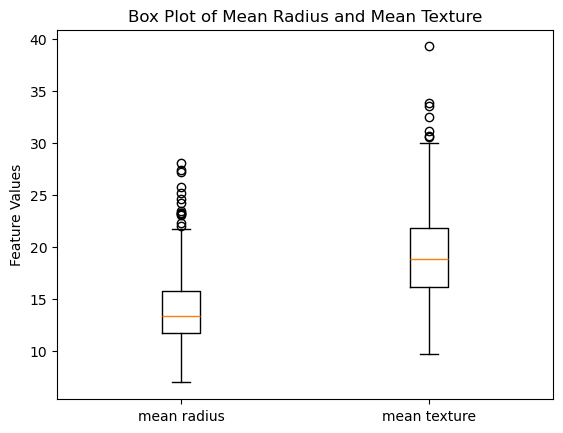

In [26]:
# To viualize outliers using box plot
import matplotlib.pyplot as plt

features = ['mean radius', 'mean texture']

plt.boxplot([df['mean radius'], df['mean texture']],
            tick_labels=features)

plt.title('Box Plot of Mean Radius and Mean Texture')
plt.ylabel('Feature Values')
plt.show()

In [38]:
# Handling outliers

# Remove rows where outliers are detected using IQR
df_no_outliers_iqr = df[df['isOutlier_IQR'] == False]

print("Original dataset size:", df.shape)
print("\n")
print("After removing IQR outliers:", df_no_outliers_iqr.shape)
print("\n")
print(df_no_outliers_iqr)


Original dataset size: (569, 35)


After removing IQR outliers: (548, 35)


     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0         

In [37]:

# Remove rows where outliers are detected using Z-score
df_no_outliers_z = df[df['isOutlier_Z'] == False]

print("Original dataset size:", df.shape)
print("\n")
print("After removing Z-score outliers:", df_no_outliers_z.shape)
print("\n")
print(df_no_outliers_z)


Original dataset size: (569, 35)


After removing Z-score outliers: (560, 35)


     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0     

In [59]:
# Replace outliers with median value (IQR Method)

# Calculate median
features = ['mean radius', 'mean texture']

median_mean_radius = df['mean radius'].median()
median_mean_texture = df['mean texture'].median()

print("Median of mean radius:", median_mean_radius)
print("Median of mean texture:", median_mean_texture)
print("\n")

# create a copy and replace outliers with median
df_iqr_median = df.copy()

df_iqr_median.loc[df_iqr_median['isOutlier_IQR'], 'mean radius'] = median_mean_radius
df_iqr_median.loc[df_iqr_median['isOutlier_IQR'], 'mean texture'] = median_mean_texture

# print the rows where outliers are modified
print("IQR Outliers replaced with median values:\n")

print(df_iqr_median.loc[df_iqr_median['isOutlier_IQR'],
                        ['mean radius', 'mean texture', 'isOutlier_IQR']])

print("Before replacement:")
print(df.loc[df['isOutlier_IQR'], features])

print("\nAfter replacement:")
print(df_iqr_median.loc[df_iqr_median['isOutlier_IQR'], features])




Median of mean radius: 13.37
Median of mean texture: 18.84


IQR Outliers replaced with median values:

     mean radius  mean texture  isOutlier_IQR
82         13.37         18.84           True
108        13.37         18.84           True
122        13.37         18.84           True
164        13.37         18.84           True
180        13.37         18.84           True
202        13.37         18.84           True
212        13.37         18.84           True
219        13.37         18.84           True
232        13.37         18.84           True
236        13.37         18.84           True
239        13.37         18.84           True
259        13.37         18.84           True
265        13.37         18.84           True
339        13.37         18.84           True
352        13.37         18.84           True
369        13.37         18.84           True
455        13.37         18.84           True
461        13.37         18.84           True
503        13.37      

In [57]:
# Replace outliers with median value (z-score Method)

# Calculate median
features = ['mean radius', 'mean texture']

median_mean_radius = df['mean radius'].median()
median_mean_texture = df['mean texture'].median()

print("Median of mean radius:", median_mean_radius)
print("Median of mean texture:", median_mean_texture)
print("\n")

# create a copy and replace outliers with median
df_iqr_median = df.copy()

df_z_median = df.copy()

df_z_median.loc[df_z_median['isOutlier_Z'], 'mean radius'] = median_mean_radius
df_z_median.loc[df_z_median['isOutlier_Z'], 'mean texture'] = median_mean_texture


# print the rows where outliers are modified
print("Z-score Outliers replaced with median values:\n")

print(df_z_median.loc[df_z_median['isOutlier_Z'],
                      ['mean radius', 'mean texture', 'isOutlier_Z']])

print("Before replacement:")
print(df.loc[df['isOutlier_Z'], features])

print("\nAfter replacement:")
print(df_z_median.loc[df_z_median['isOutlier_Z'], features])



Median of mean radius: 13.37
Median of mean texture: 18.84


Z-score Outliers replaced with median values:

     mean radius  mean texture  isOutlier_Z
82         13.37         18.84         True
180        13.37         18.84         True
212        13.37         18.84         True
219        13.37         18.84         True
232        13.37         18.84         True
239        13.37         18.84         True
259        13.37         18.84         True
352        13.37         18.84         True
461        13.37         18.84         True
Before replacement:
     mean radius  mean texture
82         25.22         24.91
180        27.22         21.87
212        28.11         18.47
219        19.53         32.47
232        11.22         33.81
239        17.46         39.28
259        15.53         33.56
352        25.73         17.46
461        27.42         26.27

After replacement:
     mean radius  mean texture
82         13.37         18.84
180        13.37         18.84
212      

In [65]:
# Feature Scaling 
# Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

features = ['mean radius', 'mean texture']
scaler = MinMaxScaler()

# Apply Min-Max scaling
df_scaled = df.copy()  # keep original safe
df_scaled[features] = scaler.fit_transform(df_scaled[features])


# After Min-Max scaling the values are between 0 and 1
print("After Min-Max scaling the values are between 0 and 1\n")
print("\nFeature min values:\n", df_scaled[features].min())
print("Feature max values:\n", df_scaled[features].max())
df_scaled[features]


After Min-Max scaling the values are between 0 and 1


Feature min values:
 mean radius     0.0
mean texture    0.0
dtype: float64
Feature max values:
 mean radius     1.0
mean texture    1.0
dtype: float64


,mean radius,mean texture
0,0.521037,0.022658
1,0.643144,0.272574
2,0.601496,0.390260
3,0.210090,0.360839
4,0.629893,0.156578
...,...,...
564,0.690000,0.428813
565,0.622320,0.626987
566,0.455251,0.621238
567,0.644564,0.663510


In [68]:
# Feature Scaling
# Standardization

# import Standard Scaler
from sklearn.preprocessing import StandardScaler

features = ['mean radius', 'mean texture']
scaler = StandardScaler()

# Create a copy to preserve original data
df_standardized = df.copy()

# Apply standardization
df_standardized[features] = scaler.fit_transform(df_standardized[features])

print(df_standardized[features].head())
print("\n")
# After standardization, mean is closer to 0 and standard deviation is closer to 1
print("After standardization, mean is closer to 0 and standard deviation is closer to 1\n")
# Check mean and standard deviation
print("\nMeans after standardization:\n", df_standardized[features].mean())
print("Standard deviations after standardization:\n", df_standardized[features].std())
print("\n")
df_standardized[features]




   mean radius  mean texture
0     1.097064     -2.073335
1     1.829821     -0.353632
2     1.579888      0.456187
3    -0.768909      0.253732
4     1.750297     -1.151816


After standardization, mean is closer to 0 and standard deviation is closer to 1


Means after standardization:
 mean radius    -1.373633e-16
mean texture    6.868164e-17
dtype: float64
Standard deviations after standardization:
 mean radius     1.00088
mean texture    1.00088
dtype: float64




,mean radius,mean texture
0,1.097064,-2.073335
1,1.829821,-0.353632
2,1.579888,0.456187
3,-0.768909,0.253732
4,1.750297,-1.151816
...,...,...
564,2.110995,0.721473
565,1.704854,2.085134
566,0.702284,2.045574
567,1.838341,2.336457


### Reflection: Importance of Feature Scaling and Handling Outliers

**Handling Outliers** and **Feature Scaling** are two importanat data preprocessing steps. In Machine Learning, the accuracy and performance of model depends on the quality of the data used. The data has to be unbiased, cleaned, normalized or standardazied before executing data driven analysis or training model or while validating the model. This minimizes loss during actual testing with real world data.

**How outliers affect model performance?**
Outliers are data points that differ significantly from the rest of a dataset, appearing as unusually high or low values.They can indicate measurement errors, anomalies, or valid but rare occurrences. While they often skew statistical results like the mean and standard deviation, they can also provide valuable insights. If the outliers are due to fault or error, we need to remove them. After investigation, if we feel, the outliers can add value, we can imputate with boundary values like 0 or 1 or with mean. By preprocessing the outliers, helps to reduce prediction error on real world unseen data. So it is crucial to investigate and handle outliers, to optimize the performance of the model in machine learning.

**Advantage of using Feature Scaling:**
Standardization ensures that all features are on the same scale. It is crucial for algorithms sensitive to feature magnitude like SVM. For example, in this assignment we applied standardization using StandardScaler from sklearn.preprocessing, that scaled the values so that the mean of values is closer to zero and standard deviation is closer to 1. We also used Min-Max scaling from sklearn.preprocessing in this assignment. It helps to transform the feature values within 0 to 1 range. This normalization ensures that all features contribute equally to distance-based algorithms and prevents features with larger ranges from dominating the model. In conclusion, Feature scaling is a crucial preprocessing step in machine learning that normalizes the range of independent variables, ensuring all features contribute equally to the model. It significantly improves model's reliability.


